<a href="https://colab.research.google.com/github/Rachitsingh13/Student-Prediction/blob/main/week5_yuva_revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET INFORMATION
Dataset shape: (2966, 8)

Columns:
['Age', 'Gender', 'Stream', 'Internships', 'CGPA', 'Hostel', 'HistoryOfBacklogs', 'PlacedOrNot']

First 5 rows:
   Age  Gender                         Stream  Internships  CGPA  Hostel  \
0   22    Male  Electronics And Communication            1     8       1   
1   21  Female               Computer Science            0     7       1   
2   22  Female         Information Technology            1     6       0   
3   21    Male         Information Technology            0     8       0   
4   22    Male                     Mechanical            0     8       1   

   HistoryOfBacklogs  PlacedOrNot  
0                  1            1  
1                  1            1  
2                  0            1  
3                  1            1  
4                  0            1  

MISSING VALUES
Age                  0
Gender               0
Stream               0
Internships          0
CGPA                 0
Hostel               0
Histor

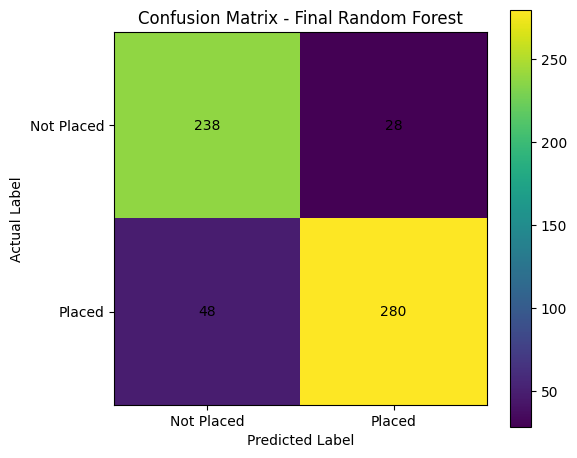

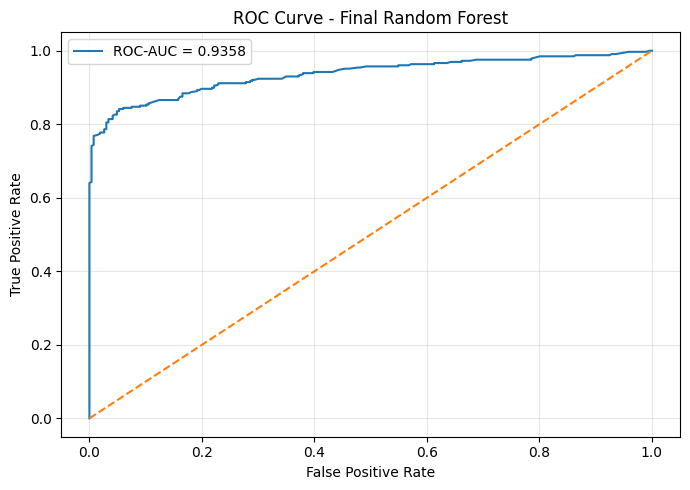

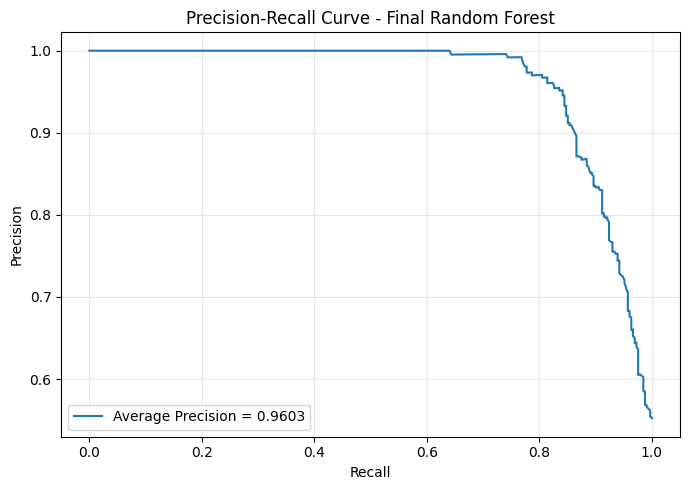


BOOTSTRAP CONFIDENCE INTERVALS
           Metric  Bootstrap Mean  95% CI Lower  95% CI Upper
         Accuracy          0.8723        0.8451        0.8990
        Precision          0.9085        0.8754        0.9391
           Recall          0.8544        0.8139        0.8899
               F1          0.8805        0.8535        0.9059
          ROC-AUC          0.9361        0.9147        0.9564
Average Precision          0.9604        0.9463        0.9719

PERMUTATION FEATURE IMPORTANCE
          Feature  Importance Mean  Importance Std
             CGPA           0.3250          0.0191
      Internships           0.0568          0.0077
              Age           0.0280          0.0061
           Stream           0.0183          0.0067
HistoryOfBacklogs           0.0052          0.0030
           Gender           0.0008          0.0025
           Hostel          -0.0001          0.0029


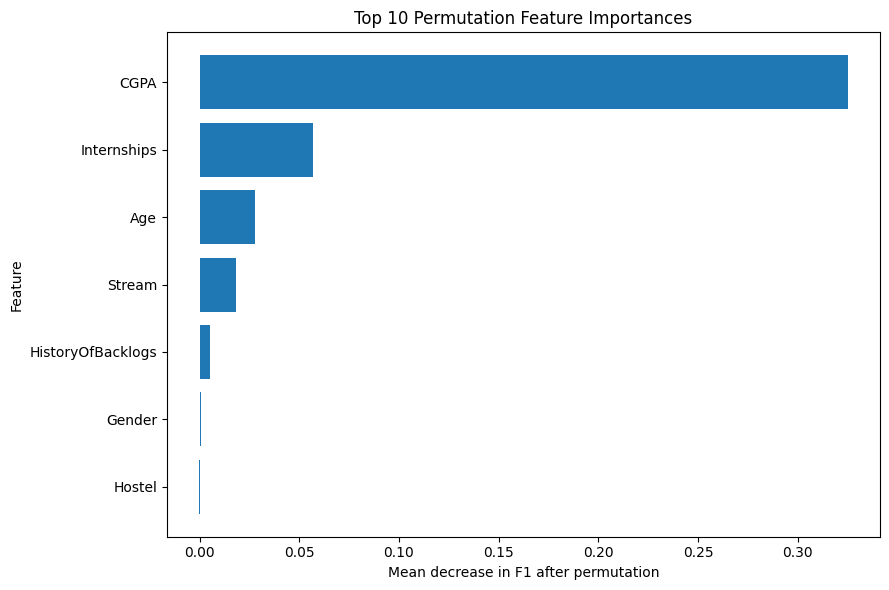


SHAP EXPLAINABILITY

Top SHAP features:
                                          Feature  Mean Absolute SHAP
                                    numeric__CGPA              0.3196
                             numeric__Internships              0.0662
                                     numeric__Age              0.0479
             categorical__Stream_Computer Science              0.0153
                        categorical__Stream_Civil              0.0140
                   categorical__Stream_Mechanical              0.0121
                                  numeric__Hostel              0.0107
                       numeric__HistoryOfBacklogs              0.0101
       categorical__Stream_Information Technology              0.0088
categorical__Stream_Electronics And Communication              0.0071
                   categorical__Stream_Electrical              0.0065
                       categorical__Gender_Female              0.0037
                         categorical__Gender_Male

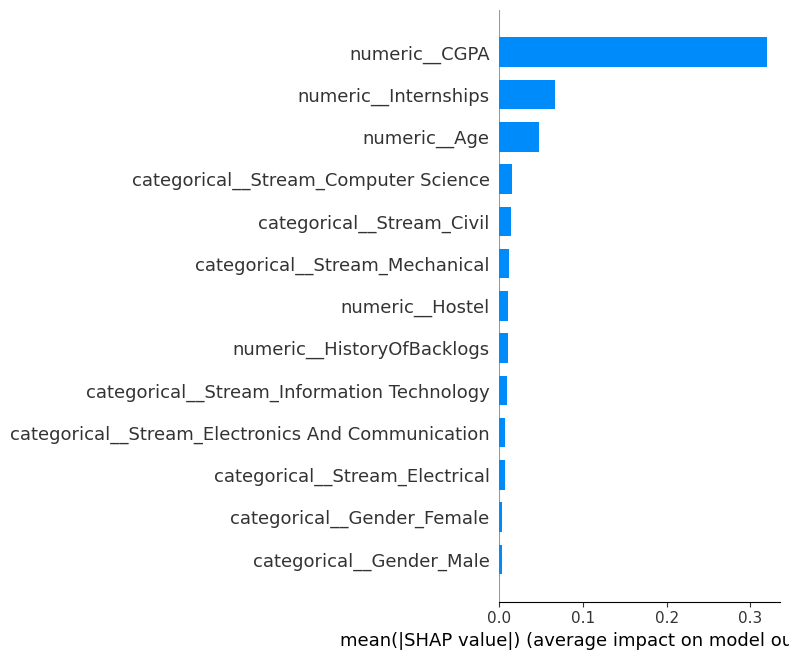

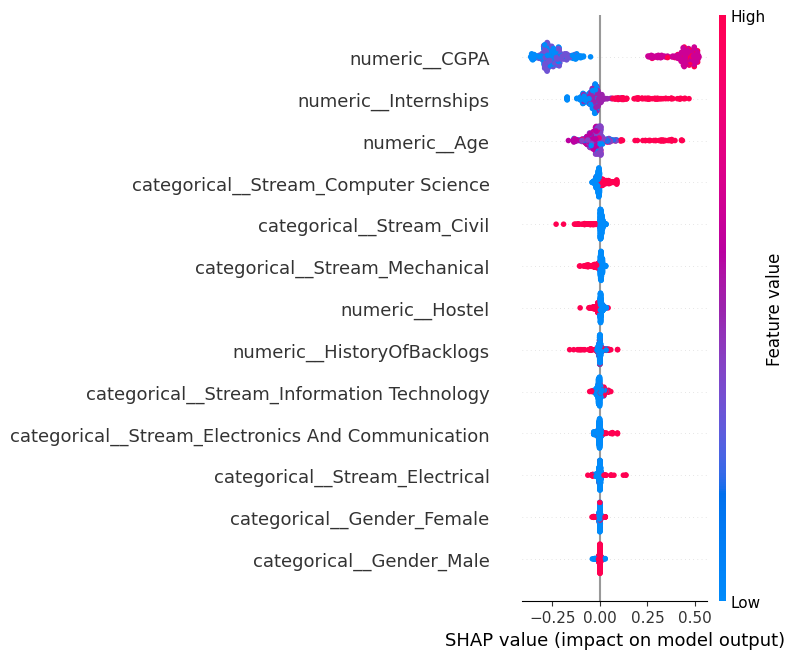


SHAP explanation for test sample:
Original index: 458
Actual value: 1
Predicted value: 0
Placement probability: 0.254


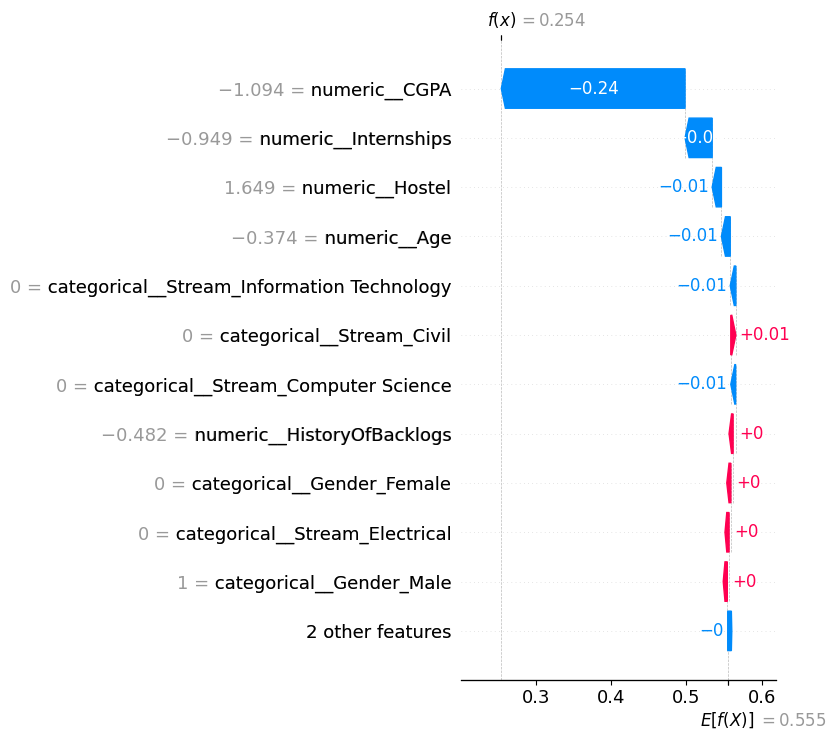


ERROR ANALYSIS
Prediction_Type
True Positive     280
True Negative     238
False Negative     48
False Positive     28
Name: count, dtype: int64

FALSE POSITIVE EXAMPLES
      Age  Gender                         Stream  Internships  CGPA  Hostel  HistoryOfBacklogs  Actual  Predicted  Placement_Probability Prediction_Type
2390   19    Male  Electronics And Communication            1     7       0                  1       0          1               0.723722  False Positive
1340   24    Male         Information Technology            1     7       0                  0       0          1               0.796329  False Positive
1584   24  Female  Electronics And Communication            0     5       0                  0       0          1               0.539778  False Positive
1092   22    Male  Electronics And Communication            2     7       0                  0       0          1               0.561239  False Positive
2907   22    Male  Electronics And Communication            2   

In [1]:
# ============================================================
# WEEK 5 - MODEL EVALUATION, VALIDATION & INTERPRETABILITY
# STUDENT PLACEMENT PREDICTION
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.inspection import permutation_importance

from sklearn.base import clone

import joblib


# ============================================================
# 2. OPTIONAL SHAP IMPORT
# ============================================================

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP is not installed.")
    print("Install it using: pip install shap")


# ============================================================
# 3. CREATE OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "week5_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# 4. LOAD DATASET
# ============================================================

# CHANGE THIS PATH IF REQUIRED
DATA_PATH = "/content/collegePlace.csv"

df = pd.read_csv(DATA_PATH)


print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 5. BASIC DATA CHECK
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

print(df.isnull().sum())


print("\n" + "=" * 70)
print("TARGET DISTRIBUTION")
print("=" * 70)

print(df["PlacedOrNot"].value_counts())

print("\nTarget percentage:")
print(
    df["PlacedOrNot"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# ============================================================
# 6. DEFINE FEATURES AND TARGET
# ============================================================

TARGET = "PlacedOrNot"

X = df.drop(columns=[TARGET])
y = df[TARGET]


# ============================================================
# 7. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


print("\n" + "=" * 70)
print("FEATURE TYPES")
print("=" * 70)

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# ============================================================
# 8. TRAIN-TEST SPLIT
# ============================================================

# IMPORTANT:
# Test data is NEVER used for model selection.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\n" + "=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 9. PREPROCESSING
# ============================================================

# Numerical:
# Missing values -> Median
#                 -> StandardScaler

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


# Categorical:
# Missing values -> Most Frequent
#                 -> One Hot Encoding

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


# ============================================================
# 10. STRATIFIED 5-FOLD CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 11. BASELINE RANDOM FOREST
# ============================================================

baseline_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])


# ============================================================
# 12. BASELINE CROSS-VALIDATION
# ============================================================

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}


baseline_cv = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)


baseline_results = {
    "Accuracy": baseline_cv["test_accuracy"].mean(),
    "Precision": baseline_cv["test_precision"].mean(),
    "Recall": baseline_cv["test_recall"].mean(),
    "F1": baseline_cv["test_f1"].mean(),
    "ROC-AUC": baseline_cv["test_roc_auc"].mean(),
    "Average Precision": baseline_cv[
        "test_average_precision"
    ].mean()
}


print("\n" + "=" * 70)
print("BASELINE RANDOM FOREST - 5 FOLD CV")
print("=" * 70)

for metric, value in baseline_results.items():
    print(f"{metric}: {value:.4f}")


# ============================================================
# 13. RANDOM FOREST HYPERPARAMETER SEARCH
# ============================================================

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)


model_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        rf
    )
])


# Keep grid reasonable so execution is practical.

param_grid = {
    "classifier__n_estimators": [
        100,
        200,
        300
    ],

    "classifier__max_depth": [
        None,
        5,
        10,
        20
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        4
    ],

    "classifier__max_features": [
        "sqrt",
        "log2"
    ],

    "classifier__class_weight": [
        None,
        "balanced"
    ]
}


# ============================================================
# 14. GRID SEARCH
# ============================================================

print("\n" + "=" * 70)
print("GRID SEARCH")
print("=" * 70)

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)


grid_search.fit(
    X_train,
    y_train
)


print("\nBest parameters:")
print(grid_search.best_params_)

print(
    "\nBest CV F1:",
    round(grid_search.best_score_, 4)
)


# ============================================================
# 15. FINAL SELECTED MODEL
# ============================================================

final_model = grid_search.best_estimator_


# ============================================================
# 16. DETAILED CROSS-VALIDATION OF FINAL MODEL
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL - 5 FOLD CROSS VALIDATION")
print("=" * 70)


cv_results = cross_validate(
    final_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)


cv_summary = []


metric_names = [
    ("accuracy", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1"),
    ("roc_auc", "ROC-AUC"),
    ("average_precision", "Average Precision")
]


for score_name, display_name in metric_names:

    scores = cv_results[
        "test_" + score_name
    ]

    cv_summary.append({
        "Metric": display_name,
        "Mean": scores.mean(),
        "Std": scores.std(),
        "Minimum": scores.min(),
        "Maximum": scores.max()
    })


cv_summary_df = pd.DataFrame(cv_summary)


print(
    cv_summary_df.round(4).to_string(
        index=False
    )
)


cv_summary_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "cross_validation_results.csv"
    ),
    index=False
)


# ============================================================
# 17. FIT FINAL MODEL ON COMPLETE TRAINING DATA
# ============================================================

final_model.fit(
    X_train,
    y_train
)


# ============================================================
# 18. FINAL TEST SET PREDICTION
# ============================================================

y_pred = final_model.predict(X_test)

y_probability = final_model.predict_proba(
    X_test
)[:, 1]


# ============================================================
# 19. FINAL TEST METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

average_precision = average_precision_score(
    y_test,
    y_probability
)


test_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Average Precision"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        average_precision
    ]
})


print("\n" + "=" * 70)
print("FINAL TEST SET RESULTS")
print("=" * 70)

print(
    test_results.round(4).to_string(
        index=False
    )
)


test_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "final_test_results.csv"
    ),
    index=False
)


# ============================================================
# 20. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# 21. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)


plt.figure(figsize=(6, 5))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Confusion Matrix - Final Random Forest"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Not Placed", "Placed"]
)

plt.yticks(
    [0, 1],
    ["Not Placed", "Placed"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "confusion_matrix.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 22. ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)


plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Final Random Forest"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "roc_curve.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 23. PRECISION-RECALL CURVE
# ============================================================

precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_probability
    )
)


plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values,
    label=f"Average Precision = {average_precision:.4f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve - Final Random Forest"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "precision_recall_curve.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 24. BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================

print("\n" + "=" * 70)
print("BOOTSTRAP CONFIDENCE INTERVALS")
print("=" * 70)


def bootstrap_metric(
    y_true,
    y_pred,
    y_prob,
    metric_name,
    n_iterations=1000,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )

    values = []

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    n = len(y_true)

    for _ in range(n_iterations):

        indices = rng.integers(
            0,
            n,
            size=n
        )

        true_sample = y_true[indices]
        pred_sample = y_pred[indices]
        prob_sample = y_prob[indices]

        try:

            if metric_name == "Accuracy":

                score = accuracy_score(
                    true_sample,
                    pred_sample
                )

            elif metric_name == "Precision":

                score = precision_score(
                    true_sample,
                    pred_sample,
                    zero_division=0
                )

            elif metric_name == "Recall":

                score = recall_score(
                    true_sample,
                    pred_sample,
                    zero_division=0
                )

            elif metric_name == "F1":

                score = f1_score(
                    true_sample,
                    pred_sample,
                    zero_division=0
                )

            elif metric_name == "ROC-AUC":

                # AUC requires both classes.
                if len(np.unique(true_sample)) < 2:
                    continue

                score = roc_auc_score(
                    true_sample,
                    prob_sample
                )

            elif metric_name == "Average Precision":

                score = average_precision_score(
                    true_sample,
                    prob_sample
                )

            else:

                raise ValueError(
                    "Unknown metric"
                )

            values.append(score)

        except Exception:
            continue


    values = np.asarray(values)

    lower = np.percentile(
        values,
        2.5
    )

    upper = np.percentile(
        values,
        97.5
    )

    return (
        values.mean(),
        lower,
        upper
    )


bootstrap_results = []


bootstrap_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "Average Precision"
]


for metric in bootstrap_metrics:

    mean_value, lower, upper = bootstrap_metric(
        y_test,
        y_pred,
        y_probability,
        metric,
        n_iterations=1000,
        random_state=42
    )

    bootstrap_results.append({
        "Metric": metric,
        "Bootstrap Mean": mean_value,
        "95% CI Lower": lower,
        "95% CI Upper": upper
    })


bootstrap_df = pd.DataFrame(
    bootstrap_results
)


print(
    bootstrap_df.round(4).to_string(
        index=False
    )
)


bootstrap_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "bootstrap_confidence_intervals.csv"
    ),
    index=False
)


# ============================================================
# 25. PERMUTATION FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 70)
print("PERMUTATION FEATURE IMPORTANCE")
print("=" * 70)


permutation = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)


feature_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": permutation.importances_mean,
    "Importance Std": permutation.importances_std
})


feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance Mean",
        ascending=False
    )
)


print(
    feature_importance_df.round(4)
    .to_string(index=False)
)


feature_importance_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "permutation_feature_importance.csv"
    ),
    index=False
)


# Plot top features

top_features = feature_importance_df.head(10)


plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance Mean"][::-1]
)

plt.xlabel(
    "Mean decrease in F1 after permutation"
)

plt.ylabel("Feature")

plt.title(
    "Top 10 Permutation Feature Importances"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "permutation_feature_importance.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 26. GET TRANSFORMED FEATURE NAMES FOR SHAP
# ============================================================

print("\n" + "=" * 70)
print("SHAP EXPLAINABILITY")
print("=" * 70)


if SHAP_AVAILABLE:

    fitted_preprocessor = (
        final_model
        .named_steps["preprocessor"]
    )

    fitted_classifier = (
        final_model
        .named_steps["classifier"]
    )


    # Transform training and test data

    X_train_transformed = (
        fitted_preprocessor
        .transform(X_train)
    )

    X_test_transformed = (
        fitted_preprocessor
        .transform(X_test)
    )


    # Obtain transformed feature names

    try:

        transformed_feature_names = (
            fitted_preprocessor
            .get_feature_names_out()
        )

    except Exception:

        transformed_feature_names = [
            f"Feature_{i}"
            for i in range(
                X_train_transformed.shape[1]
            )
        ]


    # Convert to DataFrame

    X_test_shap = pd.DataFrame(
        X_test_transformed,
        columns=transformed_feature_names,
        index=X_test.index
    )


    # ========================================================
    # 27. SHAP TREE EXPLAINER
    # ========================================================

    explainer = shap.TreeExplainer(
        fitted_classifier
    )


    shap_values = explainer.shap_values(
        X_test_shap
    )


    # SHAP versions may return:
    # 1. list of arrays
    # 2. 3-dimensional array
    # 3. 2-dimensional array

    if isinstance(shap_values, list):

        # Binary classification:
        # class 1 explanations

        shap_class1 = shap_values[1]

    elif isinstance(shap_values, np.ndarray):

        if shap_values.ndim == 3:

            # Usually:
            # samples x features x classes

            shap_class1 = shap_values[:, :, 1]

        else:

            shap_class1 = shap_values

    else:

        shap_class1 = np.asarray(
            shap_values
        )


    # ========================================================
    # 28. GLOBAL SHAP IMPORTANCE
    # ========================================================

    mean_abs_shap = np.abs(
        shap_class1
    ).mean(axis=0)


    shap_importance_df = pd.DataFrame({
        "Feature": transformed_feature_names,
        "Mean Absolute SHAP": mean_abs_shap
    })


    shap_importance_df = (
        shap_importance_df
        .sort_values(
            by="Mean Absolute SHAP",
            ascending=False
        )
    )


    print("\nTop SHAP features:")

    print(
        shap_importance_df.head(15)
        .round(4)
        .to_string(index=False)
    )


    shap_importance_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "shap_feature_importance.csv"
        ),
        index=False
    )


    # ========================================================
    # 29. SHAP SUMMARY BAR PLOT
    # ========================================================

    plt.figure()

    shap.summary_plot(
        shap_class1,
        X_test_shap,
        plot_type="bar",
        show=False,
        max_display=15
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "shap_summary_bar.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # ========================================================
    # 30. SHAP BEESWARM PLOT
    # ========================================================

    plt.figure()

    shap.summary_plot(
        shap_class1,
        X_test_shap,
        show=False,
        max_display=15
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "shap_beeswarm.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # ========================================================
    # 31. LOCAL SHAP EXAMPLE
    # ========================================================

    # Explain the first test example

    sample_position = 0

    print("\nSHAP explanation for test sample:")

    print(
        "Original index:",
        X_test.index[sample_position]
    )

    print(
        "Actual value:",
        y_test.iloc[sample_position]
    )

    print(
        "Predicted value:",
        y_pred[sample_position]
    )

    print(
        "Placement probability:",
        round(
            y_probability[sample_position],
            4
        )
    )


    # Waterfall plot

    try:

        explanation = shap.Explanation(
            values=shap_class1[
                sample_position
            ],

            base_values=(
                explainer.expected_value[1]
                if np.ndim(
                    explainer.expected_value
                ) > 0
                else explainer.expected_value
            ),

            data=X_test_shap.iloc[
                sample_position
            ].values,

            feature_names=(
                transformed_feature_names
            )
        )


        plt.figure()

        shap.plots.waterfall(
            explanation,
            max_display=12,
            show=False
        )

        plt.tight_layout()

        plt.savefig(
            os.path.join(
                OUTPUT_DIR,
                "shap_local_example.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

    except Exception as e:

        print(
            "Local SHAP plot could not be generated:",
            e
        )


else:

    print(
        "\nSHAP analysis skipped because "
        "the shap package is not installed."
    )


# ============================================================
# 32. ERROR ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)


error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values

error_analysis["Predicted"] = y_pred

error_analysis["Placement_Probability"] = (
    y_probability
)


def classify_prediction(row):

    actual = row["Actual"]
    predicted = row["Predicted"]

    if actual == 1 and predicted == 1:
        return "True Positive"

    elif actual == 0 and predicted == 0:
        return "True Negative"

    elif actual == 0 and predicted == 1:
        return "False Positive"

    else:
        return "False Negative"


error_analysis["Prediction_Type"] = (
    error_analysis.apply(
        classify_prediction,
        axis=1
    )
)


print(
    error_analysis[
        "Prediction_Type"
    ].value_counts()
)


# Save complete error analysis

error_analysis.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "error_analysis.csv"
    ),
    index=False
)


# ============================================================
# 33. SHOW CONCRETE FALSE POSITIVE EXAMPLES
# ============================================================

false_positives = error_analysis[
    error_analysis["Prediction_Type"]
    == "False Positive"
]


print("\n" + "=" * 70)
print("FALSE POSITIVE EXAMPLES")
print("=" * 70)

if len(false_positives) > 0:

    print(
        false_positives.head(5)
        .to_string()
    )

else:

    print("No false-positive examples found.")


# ============================================================
# 34. SHOW CONCRETE FALSE NEGATIVE EXAMPLES
# ============================================================

false_negatives = error_analysis[
    error_analysis["Prediction_Type"]
    == "False Negative"
]


print("\n" + "=" * 70)
print("FALSE NEGATIVE EXAMPLES")
print("=" * 70)

if len(false_negatives) > 0:

    print(
        false_negatives.head(5)
        .to_string()
    )

else:

    print("No false-negative examples found.")


# ============================================================
# 35. SAVE FINAL MODEL
# ============================================================

MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "student_placement_model.pkl"
)


joblib.dump(
    final_model,
    MODEL_PATH
)


print("\n" + "=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(
    "Saved to:",
    MODEL_PATH
)


# ============================================================
# 36. SAVE BEST PARAMETERS
# ============================================================

best_params_df = pd.DataFrame(
    [
        grid_search.best_params_
    ]
)


best_params_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "best_parameters.csv"
    ),
    index=False
)


# ============================================================
# 37. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(
    f"Accuracy           : {accuracy:.4f}"
)

print(
    f"Precision          : {precision:.4f}"
)

print(
    f"Recall             : {recall:.4f}"
)

print(
    f"F1 Score           : {f1:.4f}"
)

print(
    f"ROC-AUC            : {roc_auc:.4f}"
)

print(
    f"Average Precision  : {average_precision:.4f}"
)

print(
    "\nBest Parameters:"
)

print(
    grid_search.best_params_
)

print(
    "\nAll Week 5 outputs saved in:",
    OUTPUT_DIR
)